In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
from math import sqrt
import ROOT
import ctypes
try:
#     plt.style.use('belle2')
    plt.style.use('belle2_serif')
#     plt.style.use('belle2_modern')
except OSError:
    print("Please install belle2 matplotlib style") 
px = 1/plt.rcParams['figure.dpi']

from main.data_tools.extract_ntuples import get_pd, get_np
from main.draw_tools.decorations import b2helix, watermark
from main.draw_tools.stacking_with_error_bars import MC_stack_plot, MC_stack_plot_density

from main.data_tools.error_bars import make_data_weight
from main.data_tools.query_dataframes import cut_dfs_7types

from matplotlib.ticker import ScalarFormatter


Welcome to JupyROOT 6.26/04


In [2]:
from math import sqrt

# Error-weighted combination function
def combine_error_weighted(x, y, x_err, y_err):
    central_value = (x / x_err**2 + y / y_err**2) / (1 / x_err**2 + 1 / y_err**2)
    error = 1 / sqrt(1 / x_err**2 + 1 / y_err**2)
    return central_value, error

In [3]:
# # signal_eff_error = math.sqrt(signal_eff * (1 - signal_eff) / N_gen)

# def calculate_sig_eff_err(eff, N_gen):

#     error = math.sqrt(eff * (1 - eff) / N_gen)
#     return error

In [4]:
def combine_x_plus_y_divided_by_2(x, y, x_err, y_err):
    central_value = (x+y)/2
    error = sqrt(x_err**2 +  y_err**2)/2
    return central_value, error

In [5]:
def correct_Acp_stats( Araw, Araw_err, Aref, Aref_err, Aref_pdg, Aref_K_mix):
    final_Acp = Araw - Aref + Aref_pdg + Aref_K_mix
    final_Acp_err = sqrt(Araw_err**2 + Aref_err**2)

    return final_Acp, final_Acp_err

In [6]:
def correct_Acp_stats_no_Kmix( Araw, Araw_err, Aref, Aref_err, Aref_pdg):
    final_Acp = Araw - Aref + Aref_pdg 
    final_Acp_err = sqrt(Araw_err**2 + Aref_err**2)

    return final_Acp, final_Acp_err

# MC15 full

## Acp(D+ -> eta K+)

### eta -> gg

In [9]:
# Araw_gg_cms_plus = 0.10419942720824679
# Araw_gg_cms_plus_error = 0.12031082594050302
# Araw_gg_cms_minus = 0.10895853651493069
# Araw_gg_cms_minus_error = 0.10451065565167805
# Araw_gg, Araw_gg_stats_error = combine_x_plus_y_divided_by_2(Araw_gg_cms_plus,Araw_gg_cms_minus, Araw_gg_cms_plus_error,Araw_gg_cms_minus_error )

In [10]:
#fitv12
Araw_gg_cms_plus = 0.1064171745897613
Araw_gg_cms_plus_error = 0.06465096493604734
Araw_gg_cms_minus = 0.10504291780740149
Araw_gg_cms_minus_error = 0.0621202582928456
Araw_gg, Araw_gg_stats_error = combine_x_plus_y_divided_by_2(Araw_gg_cms_plus,Araw_gg_cms_minus, Araw_gg_cms_plus_error,Araw_gg_cms_minus_error )

In [11]:
Araw_gg

0.1057300461985814

In [12]:
Araw_gg_stats_error

0.044829325662817734

In [16]:
Aref_gg_cms_plus = -0.003701149316848902
Aref_gg_cms_plus_error = 0.005921952813976071
Aref_gg_cms_minus = 0.01736962235811462
Aref_gg_cms_minus_error = 0.006144815141224785
Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

In [17]:
Aref_gg

0.0068342365206328585

In [18]:
Aref_gg_stats_error

0.004266974286622327

In [19]:
# Aref_gg = 0.0006061306395504472 
# Aref_gg_stats_error = 0.0018471929918681717

Aref_gg_pdg = 0.0009
Aref_gg_pdg_sys_error = 0.0026

Aref_K_mix = -0.00070
Aref_K_mix_sys_error = 0.00004

In [50]:
Acp_etapip_gg_value, Acp_etapip_gg_error =correct_Acp_stats(Araw_gg, Araw_gg_stats_error, Aref_gg, Aref_gg_stats_error, Aref_gg_pdg, Aref_K_mix)

In [51]:
Acp_etapip_gg_value

0.10066199987230438

In [52]:
Acp_etapip_gg_error

0.08039395711796105

### eta -> pipipi

In [14]:
# Araw_3pi_cms_plus = -0.018352017191244956
# Araw_3pi_cms_plus_error = 0.12120019447744591
# Araw_3pi_cms_minus = 0.09174977816236814
# Araw_3pi_cms_minus_error = 0.12230811424575713
# Araw_pipipi, Araw_pipipi_stats_error = combine_x_plus_y_divided_by_2(Araw_3pi_cms_plus,Araw_3pi_cms_minus, Araw_3pi_cms_plus_error,Araw_3pi_cms_minus_error )

In [15]:
#fitv12
Araw_3pi_cms_plus = -0.022011393066735163
Araw_3pi_cms_plus_error = 0.06469668073810945
Araw_3pi_cms_minus = 0.06283601481701084
Araw_3pi_cms_minus_error = 0.06271278000854053
Araw_pipipi, Araw_pipipi_stats_error = combine_x_plus_y_divided_by_2(Araw_3pi_cms_plus,Araw_3pi_cms_minus, Araw_3pi_cms_plus_error,Araw_3pi_cms_minus_error )

In [16]:
Araw_pipipi

0.02041231087513784

In [17]:
Araw_pipipi_stats_error

0.0450515073968909

In [27]:
Aref_3pi_cms_plus = -0.0008998305931825739
Aref_3pi_cms_plus_error =  0.004886107779982841
Aref_3pi_cms_minus = 0.015000885787206122
Aref_3pi_cms_minus_error = 0.005137535569726427
Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_3pi_cms_plus,Aref_3pi_cms_minus, Aref_3pi_cms_plus_error,Aref_3pi_cms_minus_error )

In [28]:
Aref_pipipi

0.007050527597011774

In [29]:
Aref_pipipi_stats_error

0.0035450077915222234

In [60]:
# Aref_pipipi = 0.0003791615573990744
# Aref_pipipi_stats_error = 0.0016987754151532451

Aref_pipipi_pdg = 0.0009
Aref_pipipi_pdg_sys_error = 0.0026

Aref_K_mix = -0.00070
Aref_K_mix_sys_error = 0.00004

In [61]:
Acp_etapip_pipipi_value, Acp_etapip_pipipi_error =correct_Acp_stats(Araw_pipipi, Araw_pipipi_stats_error, Aref_pipipi, Aref_pipipi_stats_error, Aref_pipipi_pdg, Aref_K_mix)

In [62]:
Acp_etapip_pipipi_value

0.030034355116221455

In [63]:
Acp_etapip_pipipi_error

0.0864215880025305

In [64]:
central_value_1, central_value_2, stat_unc_1, stat_unc_2 = Acp_etapip_gg_value, Acp_etapip_pipipi_value, Acp_etapip_gg_error, Acp_etapip_pipipi_error

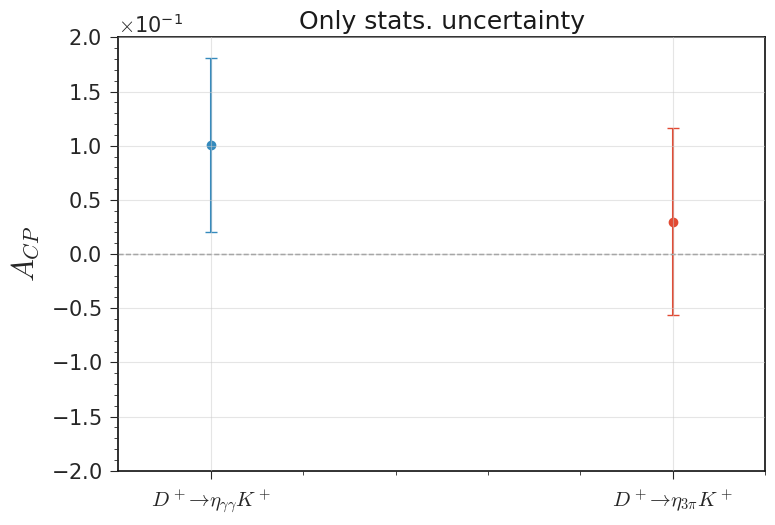

In [65]:
# Plotting
plt.errorbar(1, central_value_1, yerr=stat_unc_1, fmt='o', capsize=4)
plt.errorbar(2, central_value_2, yerr=stat_unc_2, fmt='o', capsize=4)
# plt.errorbar(3, combined_central_value, yerr=combined_error, fmt='o', capsize=4)

plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# plt.xticks([1, 2, 3], [r'$D^+ \to \eta_{\gamma\gamma} K^+$', r'$D^+ \to \eta_{3\pi} K^+$', 'Combined'], fontsize=14)
plt.xticks([1, 2], [r'$D^+ \to \eta_{\gamma\gamma} K^+$', r'$D^+ \to \eta_{3\pi} K^+$'])

plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

plt.ylabel(r'$A_{CP}$')
plt.grid(True, alpha=0.5)
plt.title("Only stats. uncertainty")

plt.ylim(-2*0.1 , 2*0.1)
plt.tight_layout()
plt.savefig("MC15rd_427_87_etaKp_Acp_v7_fitv1_corr_pdg_Kshp_bdt_Dp_CMS_p_newFOM_pdgKsmix.png")
plt.show()

In [66]:
combined_central_value, combined_error = combine_error_weighted(central_value_1, central_value_2, stat_unc_1, stat_unc_2)


In [67]:
combined_central_value

0.06789687442617968

In [68]:
combined_error

0.058862783860636425

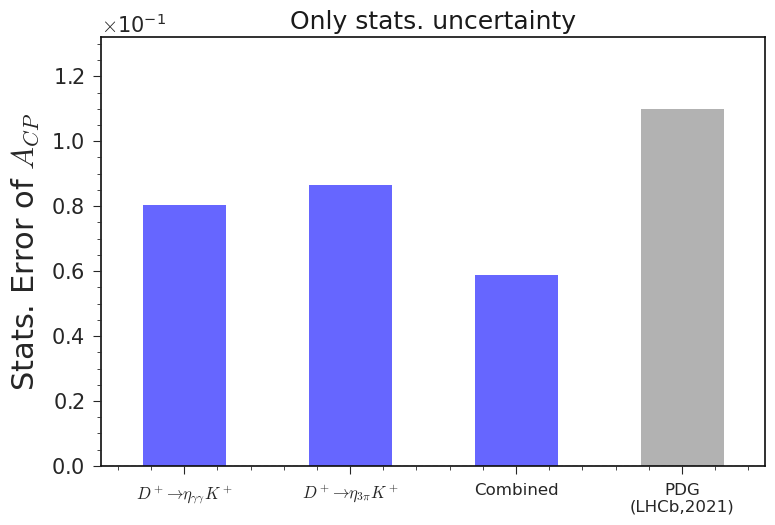

In [69]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Define the errors as bar heights
errors = [stat_unc_1, stat_unc_2, combined_error, 0.11]

colors = ['blue', 'blue', 'blue', 'gray']
# Plotting error bars as a bar graph
plt.bar([1, 2, 3, 4], errors, color=colors, alpha=0.6, width=0.5)

# Adding a horizontal line at y=0
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# Customizing plot
plt.xticks([1, 2, 3, 4], [r'$D^+ \to \eta_{\gamma\gamma} K^+$', r'$D^+ \to \eta_{3\pi} K^+$', 'Combined','PDG\n(LHCb,2021)'], fontsize=12)
plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

plt.ylabel(r'Stats. Error of $A_{CP}$')
# plt.grid(True, alpha=0.5)
plt.title("Only stats. uncertainty")

plt.ylim(0, max(errors) * 1.2)  # Adjusting y-limit to show error bars fully
plt.tight_layout()

# Save and display
plt.savefig("MC15rd_427_87_etaKp_Acp_error_bars_v7_fitv1_corr_pdg_Kshp_bdt_Dp_CMS_p_newFOM_pdgKsmix.png")

plt.show()


## Acp(Ds+ -> eta K+)

### eta -> gg

In [9]:
# Araw_gg_cms_plus = 0.026786095143596544
# Araw_gg_cms_plus_error = 0.030541589346272248
# Araw_gg_cms_minus = 0.029878811603100772
# Araw_gg_cms_minus_error = 0.03166784728334546
# Araw_gg, Araw_gg_stats_error = combine_x_plus_y_divided_by_2(Araw_gg_cms_plus,Araw_gg_cms_minus, Araw_gg_cms_plus_error,Araw_gg_cms_minus_error )

In [10]:
#fitv12
Araw_gg_cms_plus = 0.028255116978362027
Araw_gg_cms_plus_error = 0.01443567753057698
Araw_gg_cms_minus = 0.039435424547427766
Araw_gg_cms_minus_error = 0.014995730785763647
Araw_gg, Araw_gg_stats_error = combine_x_plus_y_divided_by_2(Araw_gg_cms_plus,Araw_gg_cms_minus, Araw_gg_cms_plus_error,Araw_gg_cms_minus_error )

In [11]:
Araw_gg

0.0338452707628949

In [12]:
Araw_gg_stats_error

0.01040745799374065

In [23]:
# Aref_gg = 0.0020477180350933996
# Aref_gg_stats_error = 0.0021030268194965596

# Aref_gg_pdg = -0.0038
# Aref_gg_pdg_sys_error = 0.0027


In [74]:
# Acp_etapip_gg_value, Acp_etapip_gg_error =correct_Acp_stats_no_Kmix(Araw_gg, Araw_gg_stats_error, Aref_gg, Aref_gg_stats_error, Aref_gg_pdg)

In [75]:
# Aref_gg_pdg = 0.0009
# Aref_gg_pdg_sys_error = 0.0026

In [76]:
Acp_etapip_gg_value, Acp_etapip_gg_error =correct_Acp_stats(Araw_gg, Araw_gg_stats_error, Aref_gg, Aref_gg_stats_error, Aref_gg_pdg, Aref_K_mix)

In [77]:
Acp_etapip_gg_value

0.018108957570189654

In [78]:
Acp_etapip_gg_error

0.02334695619393085

### eta -> pipipi

In [79]:
# Araw_pipipi =  0.0003362131000147013
# Araw_pipipi_stats_error = 0.005709802050462188

In [13]:
# Araw_3pi_cms_plus = -0.009557180922080565
# Araw_3pi_cms_plus_error = 0.03756326029120375
# Araw_3pi_cms_minus = 0.028235878019333117
# Araw_3pi_cms_minus_error = 0.039912488712818106
# Araw_pipipi, Araw_pipipi_stats_error = combine_x_plus_y_divided_by_2(Araw_3pi_cms_plus,Araw_3pi_cms_minus, Araw_3pi_cms_plus_error,Araw_3pi_cms_minus_error )

In [18]:
#fitv12
Araw_3pi_cms_plus = -0.010374809486891179
Araw_3pi_cms_plus_error = 0.017616495697287363
Araw_3pi_cms_minus = 0.029390746967061343
Araw_3pi_cms_minus_error = 0.018209998419019727
Araw_pipipi, Araw_pipipi_stats_error = combine_x_plus_y_divided_by_2(Araw_3pi_cms_plus,Araw_3pi_cms_minus, Araw_3pi_cms_plus_error,Araw_3pi_cms_minus_error )

In [19]:
Araw_pipipi

0.009507968740085082

In [20]:
Araw_pipipi_stats_error

0.012668316414121935

In [31]:
Aref_pipipi

0.007050527597011774

In [32]:
Aref_pipipi_stats_error

0.0035450077915222234

In [84]:
# Aref_pipipi = 0.0020154684957205933
# Aref_pipipi_stats_error = 0.0019261952673341304

# Aref_pipipi_pdg = -0.0038
# Aref_pipipi_pdg_sys_error = 0.0027



In [85]:
# Acp_etapip_pipipi_value, Acp_etapip_pipipi_error =correct_Acp_stats_no_Kmix(Araw_pipipi, Araw_pipipi_stats_error, Aref_pipipi, Aref_pipipi_stats_error, Aref_pipipi_pdg)

In [86]:

Aref_K_mix = -0.00070
Aref_K_mix_sys_error = 0.00004

In [87]:
Acp_etapip_pipipi_value, Acp_etapip_pipipi_error =correct_Acp_stats(Araw_pipipi, Araw_pipipi_stats_error, Aref_pipipi, Aref_pipipi_stats_error, Aref_pipipi_pdg, Aref_K_mix)

In [88]:
Acp_etapip_pipipi_value

-0.003190118765250107

In [89]:
Acp_etapip_pipipi_error

0.02932568252895709

In [90]:
central_value_1, central_value_2, stat_unc_1, stat_unc_2 = Acp_etapip_gg_value, Acp_etapip_pipipi_value, Acp_etapip_gg_error, Acp_etapip_pipipi_error

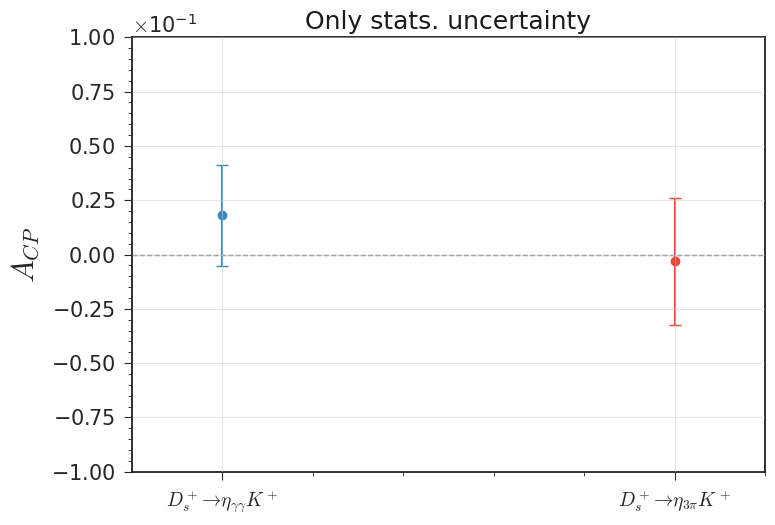

In [91]:
# Plotting
plt.errorbar(1, central_value_1, yerr=stat_unc_1, fmt='o', capsize=4)
plt.errorbar(2, central_value_2, yerr=stat_unc_2, fmt='o', capsize=4)
# plt.errorbar(3, combined_central_value, yerr=combined_error, fmt='o', capsize=4)

plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# plt.xticks([1, 2, 3], [r'$D_s^+ \to \eta_{\gamma\gamma} K^+$', r'$D_s^+ \to \eta_{3\pi} K^+$', 'Combined'], fontsize=14)
plt.xticks([1, 2], [r'$D_s^+ \to \eta_{\gamma\gamma} K^+$', r'$D_s^+ \to \eta_{3\pi} K^+$'], fontsize=14)

plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

plt.ylabel(r'$A_{CP}$')
plt.grid(True, alpha=0.5)
plt.title("Only stats. uncertainty")

plt.ylim(-10*0.01 , 10*0.01)

plt.tight_layout()
plt.savefig("MC15rd_427_87_etaKp_Acp_v7_fitv1_corr_pdg_Kshp_bdt_Dp_CMS_p_newFOM_pdgKsmix_Ds.png")

plt.show()

In [92]:
combined_central_value, combined_error = combine_error_weighted(central_value_1, central_value_2, stat_unc_1, stat_unc_2)


In [93]:
combined_central_value

0.009846267073708857

In [94]:
combined_error

0.01826537051432873

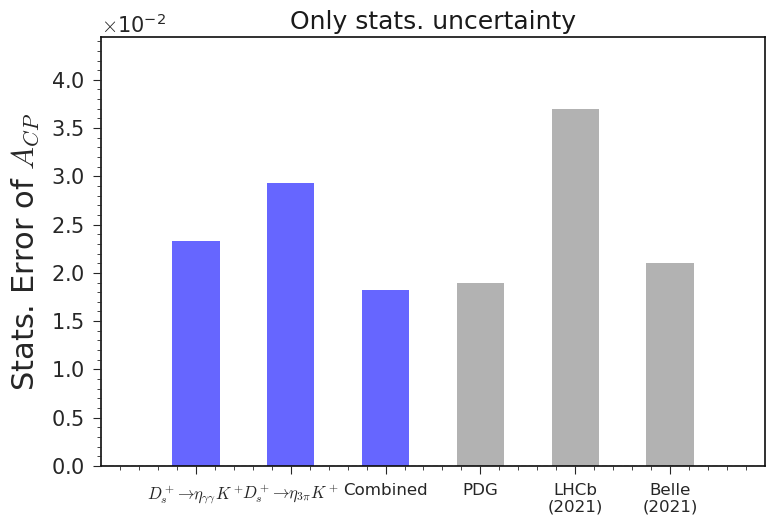

In [95]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Define the errors as bar heights
errors = [stat_unc_1, stat_unc_2, combined_error, 0.019, 0.037, 0.021]

colors = ['blue', 'blue', 'blue', 'gray', 'gray', 'gray', 'gray']

# Plotting error bars as a bar graph
plt.bar([1, 2, 3, 4, 5, 6], errors, color=colors, alpha=0.6, width=0.5)

# Adding a horizontal line at y=0
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# Customizing plot
plt.xticks([1, 2, 3, 4, 5, 6], [r'$D_s^+ \to \eta_{\gamma\gamma} K^+$', r'$D_s^+ \to \eta_{3\pi} K^+$', 'Combined','PDG','LHCb\n(2021)','Belle\n(2021)'], fontsize=12)
plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

plt.ylabel(r'Stats. Error of $A_{CP}$')
# plt.grid(True, alpha=0.5)
plt.title("Only stats. uncertainty")

plt.ylim(0, max(errors) * 1.2)  # Adjusting y-limit to show error bars fully
plt.tight_layout()

# Save and display
plt.savefig("MC15rd_427_87_etaKp_Acp_error_bars_v7_fitv1_corr_pdg_Kshp_bdt_Dp_CMS_p_newFOM_pdgKsmix_Ds.png")

plt.show()


# proc13

## Acp(D+ -> eta K+)

### eta -> gg

In [9]:
Araw_gg_cms_plus = 
Araw_gg_cms_plus_error = 
Araw_gg_cms_minus = 
Araw_gg_cms_minus_error = 
Araw_gg, Araw_gg_stats_error = combine_x_plus_y_divided_by_2(Araw_gg_cms_plus,Araw_gg_cms_minus, Araw_gg_cms_plus_error,Araw_gg_cms_minus_error )

In [10]:
Araw_gg

0.034880952051447964

In [11]:
Araw_gg_stats_error

0.00616829840179855

In [42]:
Aref_gg_cms_plus = -0.019735199217067265
Aref_gg_cms_plus_error = 0.0065911034802123795
Aref_gg_cms_minus = 0.019646070733325617
Aref_gg_cms_minus_error = 0.0069032442927141925
Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

In [43]:
Aref_gg

-4.4564241870824126e-05

In [44]:
Aref_gg_stats_error

0.004772248601334564

In [11]:
Aref_gg_pdg = 0.0009
Aref_gg_pdg_sys_error = 0.0026

In [10]:
# Aref_gg = 0.0006061306395504472 
# Aref_gg_stats_error = 0.0018471929918681717



# Aref_K_mix = -0.00070
# Aref_K_mix_sys_error = 0.00004

In [16]:
Acp_etapip_gg_value, Acp_etapip_gg_error =correct_Acp_stats(Araw_gg, Araw_gg_stats_error, Aref_gg, Aref_gg_stats_error, Aref_gg_pdg, Aref_K_mix)

In [17]:
Acp_etapip_gg_value

0.02854186389966744

In [18]:
Acp_etapip_gg_error

0.006450501907993782

### eta -> pipipi

In [32]:
Araw_3pi_cms_plus = 
Araw_3pi_cms_plus_error =
Araw_3pi_cms_minus = 
Araw_3pi_cms_minus_error = 
Araw_pipipi, Araw_pipipi_stats_error = combine_x_plus_y_divided_by_2(Araw_3pi_cms_plus,Araw_3pi_cms_minus, Araw_3pi_cms_plus_error,Araw_3pi_cms_minus_error )

In [12]:
Aref_3pi_cms_plus = -0.025290608630696345
Aref_3pi_cms_plus_error = 0.005442537832797415
Aref_3pi_cms_minus =  0.025579177884551423
Aref_3pi_cms_minus_error = 0.005744927521207834
Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_3pi_cms_plus,Aref_3pi_cms_minus, Aref_3pi_cms_plus_error,Aref_3pi_cms_minus_error )

In [13]:
Aref_pipipi

0.00014428462692753913

In [14]:
Aref_pipipi_stats_error

0.003956810909222299

In [13]:
# Aref_pipipi = 0.0003791615573990744
# Aref_pipipi_stats_error = 0.0016987754151532451

Aref_gg_pdg = 0.0009
Aref_gg_pdg_sys_error = 0.0026

# Aref_K_mix = -0.00070
# Aref_K_mix_sys_error = 0.00004

In [20]:
Acp_etapip_pipipi_value, Acp_etapip_pipipi_error =correct_Acp_stats(Araw_pipipi, Araw_pipipi_stats_error, Aref_pipipi, Aref_pipipi_stats_error, Aref_pipipi_pdg, Aref_K_mix)

NameError: name 'Araw_pipipi' is not defined

In [21]:
Acp_etapip_pipipi_value

NameError: name 'Acp_etapip_pipipi_value' is not defined

In [22]:
Acp_etapip_pipipi_error

NameError: name 'Acp_etapip_pipipi_error' is not defined

In [37]:
central_value_1, central_value_2, stat_unc_1, stat_unc_2 = Acp_etapip_gg_value, Acp_etapip_pipipi_value, Acp_etapip_gg_error, Acp_etapip_pipipi_error

In [19]:
# Plotting
plt.errorbar(1, central_value_1, yerr=stat_unc_1, fmt='o', capsize=4)
plt.errorbar(2, central_value_2, yerr=stat_unc_2, fmt='o', capsize=4)
# plt.errorbar(3, combined_central_value, yerr=combined_error, fmt='o', capsize=4)

plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# plt.xticks([1, 2, 3], [r'$D^+ \to \eta_{\gamma\gamma} \pi^+$', r'$D^+ \to \eta_{3\pi} \pi^+$', 'Combined'], fontsize=14)
plt.xticks([1, 2], [r'$D^+ \to \eta_{\gamma\gamma} \pi^+$', r'$D^+ \to \eta_{3\pi} \pi^+$'])

plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

plt.ylabel(r'$A_{CP}$')
plt.grid(True, alpha=0.5)
plt.title("Only stats. uncertainty")

plt.ylim(-2.5*0.01 , 2.5*0.01)
plt.tight_layout()
plt.savefig("proc13_427_87_etapip_Acp_v7_fitv1_corr_Kshp_train_Dp_CMS_p.png")
plt.show()

NameError: name 'central_value_1' is not defined

In [39]:
combined_central_value, combined_error = combine_error_weighted(central_value_1, central_value_2, stat_unc_1, stat_unc_2)


In [40]:
combined_central_value

-0.0032936100330950265

In [41]:
combined_error

0.00551549227050471

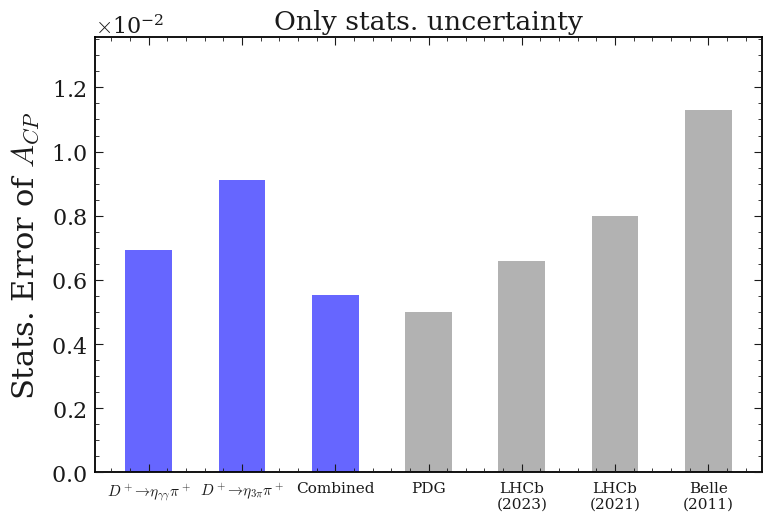

In [42]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Define the errors as bar heights
errors = [stat_unc_1, stat_unc_2, combined_error, 0.005, 0.0066, 0.008,0.0113]

colors = ['blue', 'blue', 'blue', 'gray', 'gray', 'gray', 'gray', 'gray']

# Plotting error bars as a bar graph
plt.bar([1, 2, 3, 4, 5, 6,7], errors, color=colors , alpha=0.6, width=0.5)

# Adding a horizontal line at y=0
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# Customizing plot
plt.xticks([1, 2, 3, 4, 5, 6, 7], [r'$D^+ \to \eta_{\gamma\gamma} \pi^+$', r'$D^+ \to \eta_{3\pi} \pi^+$', 'Combined','PDG','LHCb\n(2023)','LHCb\n(2021)', 'Belle\n(2011)'], fontsize=11)
plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

plt.ylabel(r'Stats. Error of $A_{CP}$')
# plt.grid(True, alpha=0.5)
plt.title("Only stats. uncertainty")

plt.ylim(0, max(errors) * 1.2)  # Adjusting y-limit to show error bars fully
plt.tight_layout()

# Save and display
plt.savefig("MC15rd_427_87_etapip_Acp_error_bars_v7_fitv1_corr_Kshp.png")
plt.show()


## Acp(Ds+ -> eta pi+)

### eta -> gg

In [25]:
Araw_gg_cms_plus = -0.05498271080164525
Araw_gg_cms_plus_error = 0.006084116397284539
Araw_gg_cms_minus = 0.08616900693513728
Araw_gg_cms_minus_error =  0.006830117340192489
Araw_gg, Araw_gg_stats_error = combine_x_plus_y_divided_by_2(Araw_gg_cms_plus,Araw_gg_cms_minus, Araw_gg_cms_plus_error,Araw_gg_cms_minus_error )

In [26]:
Araw_gg

0.002861347260549158

In [27]:
Araw_gg_stats_error

0.004193597796279087

In [28]:
# Aref_gg = 0.0020477180350933996
# Aref_gg_stats_error = 0.0021030268194965596

# Aref_gg_pdg = -0.0038
# Aref_gg_pdg_sys_error = 0.0027


In [29]:
# Acp_etapip_gg_value, Acp_etapip_gg_error =correct_Acp_stats_no_Kmix(Araw_gg, Araw_gg_stats_error, Aref_gg, Aref_gg_stats_error, Aref_gg_pdg)

In [30]:
Aref_gg_pdg = -0.0041
Aref_gg_pdg_sys_error = 0.0009

In [31]:
Acp_etapip_gg_value, Acp_etapip_gg_error =correct_Acp_stats(Araw_gg, Araw_gg_stats_error, Aref_gg, Aref_gg_stats_error, Aref_gg_pdg, Aref_K_mix)

In [32]:
Acp_etapip_gg_value

-0.003477740891231372

In [33]:
Acp_etapip_gg_error

0.004598622855633814

### eta -> pipipi

In [69]:
Araw_pipipi =  0.0003362131000147013
Araw_pipipi_stats_error = 0.005709802050462188

In [70]:
# Aref_pipipi = 0.0020154684957205933
# Aref_pipipi_stats_error = 0.0019261952673341304

# Aref_pipipi_pdg = -0.0038
# Aref_pipipi_pdg_sys_error = 0.0027



In [71]:
# Acp_etapip_pipipi_value, Acp_etapip_pipipi_error =correct_Acp_stats_no_Kmix(Araw_pipipi, Araw_pipipi_stats_error, Aref_pipipi, Aref_pipipi_stats_error, Aref_pipipi_pdg)

In [13]:
Aref_pipipi_pdg = -0.0041
Aref_pipipi_pdg_sys_error = 0.0009

Aref_K_mix = -0.00070
Aref_K_mix_sys_error = 0.00004

In [34]:
Acp_etapip_pipipi_value, Acp_etapip_pipipi_error =correct_Acp_stats(Araw_pipipi, Araw_pipipi_stats_error, Aref_pipipi, Aref_pipipi_stats_error, Aref_pipipi_pdg, Aref_K_mix)

In [72]:
Acp_etapip_pipipi_value

-0.005479255395705892

In [73]:
Acp_etapip_pipipi_error

0.006025949523798106

In [74]:
central_value_1, central_value_2, stat_unc_1, stat_unc_2 = Acp_etapip_gg_value, Acp_etapip_pipipi_value, Acp_etapip_gg_error, Acp_etapip_pipipi_error

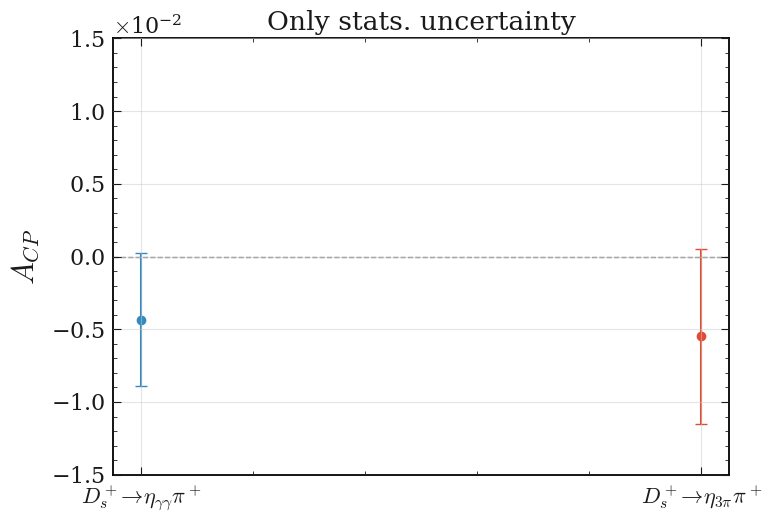

In [75]:
# Plotting
plt.errorbar(1, central_value_1, yerr=stat_unc_1, fmt='o', capsize=4)
plt.errorbar(2, central_value_2, yerr=stat_unc_2, fmt='o', capsize=4)
# plt.errorbar(3, combined_central_value, yerr=combined_error, fmt='o', capsize=4)

plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# plt.xticks([1, 2, 3], [r'$D_s^+ \to \eta_{\gamma\gamma} \pi^+$', r'$D_s^+ \to \eta_{3\pi} \pi^+$', 'Combined'], fontsize=14)
plt.xticks([1, 2], [r'$D_s^+ \to \eta_{\gamma\gamma} \pi^+$', r'$D_s^+ \to \eta_{3\pi} \pi^+$'])

plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

plt.ylabel(r'$A_{CP}$')
plt.grid(True, alpha=0.5)
plt.title("Only stats. uncertainty")

plt.ylim(-1.5*0.01 , 1.5*0.01)

plt.tight_layout()
plt.savefig("MC15rd_427_87_etapip_Acp_v7_fitv1_corr_Phipip_Ds.png")
plt.show()

In [59]:
combined_central_value, combined_error = combine_error_weighted(central_value_1, central_value_2, stat_unc_1, stat_unc_2)


In [60]:
combined_central_value

-0.00475430972667942

In [61]:
combined_error

0.0036494894913636187

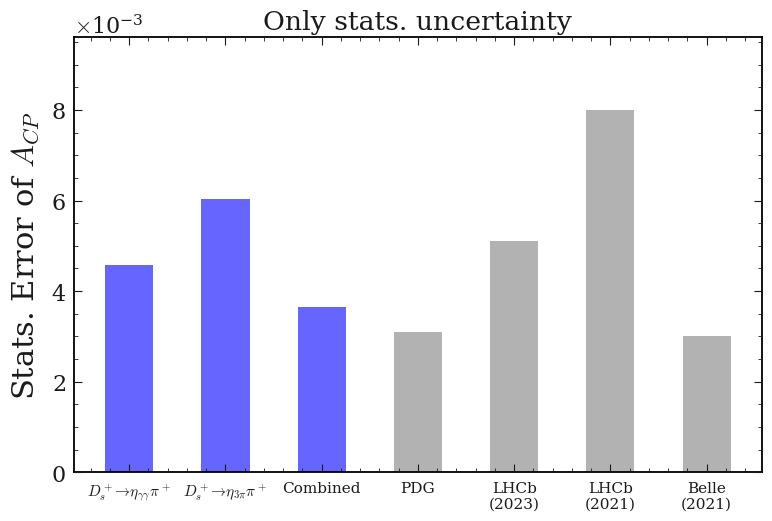

In [63]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Define the errors as bar heights
errors = [stat_unc_1, stat_unc_2, combined_error, 0.0031,0.0051, 0.008, 0.003]

colors = ['blue', 'blue', 'blue', 'gray', 'gray', 'gray', 'gray','gray']
# Plotting error bars as a bar graph
plt.bar([1, 2, 3, 4, 5, 6, 7], errors, color=colors, alpha=0.6, width=0.5)

# Adding a horizontal line at y=0
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# Customizing plot
plt.xticks([1, 2, 3, 4, 5, 6,7], [r'$D_s^+ \to \eta_{\gamma\gamma} \pi^+$', r'$D_s^+ \to \eta_{3\pi} \pi^+$', 'Combined','PDG','LHCb\n(2023)','LHCb\n(2021)','Belle\n(2021)'], fontsize=11)
plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

plt.ylabel(r'Stats. Error of $A_{CP}$')
# plt.grid(True, alpha=0.5)
plt.title("Only stats. uncertainty")

plt.ylim(0, max(errors) * 1.2)  # Adjusting y-limit to show error bars fully
plt.tight_layout()


# Save and display
plt.savefig("MC15rd_427_87_etapip_Acp_error_bars_v7_fitv1_corr_Phipip_Ds.png")
plt.show()
